# 1. Initialization and Configuration
Loading necessary libraries, setting up auto-reloading for our utils.py script, and parsing the config.yml parameters.

In [1]:
import os
import yaml
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from pymongo import MongoClient
from scipy.stats import zscore

from utils import sliding_window_pd, save_results
from utils_visual import plot_average_durations, plot_signal_histograms, plot_windows_per_class 

# Load Config
cfg = yaml.safe_load(open(os.path.join(os.getcwd(), "config.yml")))

# 2. Data Ingestion & Parquet Caching
Fetching the 27 continuous session documents directly from MongoDB. The data is flattened and cached into a .parquet file to vastly speed up subsequent runs and avoid hitting the database repeatedly.

In [2]:
coll = MongoClient(cfg["client"])[cfg["db"]][cfg["col"]]
docs = list(coll.find({}, {"_id": 0})) # Fetch 27 documents

records = []
for d in docs:
    sub = pd.DataFrame(d["data"])
    for k in ("gesture_id", "finger", "typing_style", "hand", "sr", "sensor", "primary", "spontaneous", "user", "session_id"):
        sub[k] = d[k]
    records.append(sub)

df_all = pd.concat(records, ignore_index=True)

cache_path = Path(cfg["out_cache"]) / "gestures_clean.parquet"
cache_path.parent.mkdir(parents=True, exist_ok=True)
df_all.to_parquet(cache_path)

print(f"Cached {len(df_all)} samples across {len(docs)} sessions.")

Cached 454413 samples across 27 sessions.


# 3. Signal-Level EDA & Scaling Justification
Before segmenting the data, we visualize class durations and analyze the raw signal distributions.

Justifying Mixed Scaling: By calculating the kurtosis, we prove that the gyroscope axes exhibit heavy-tailed distributions (spikes), which strictly justifies the use of a RobustScaler over a standard one.

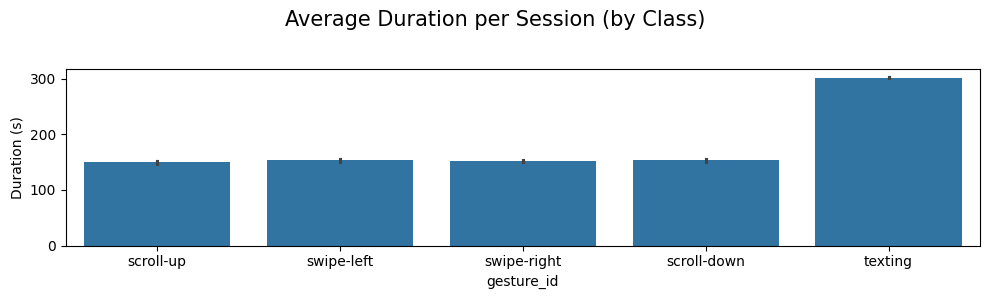

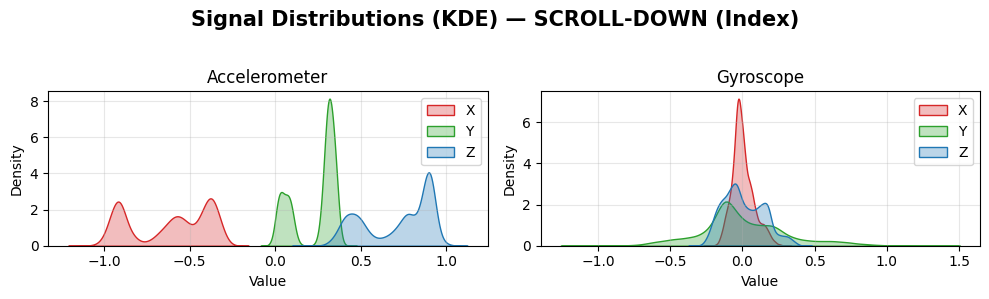

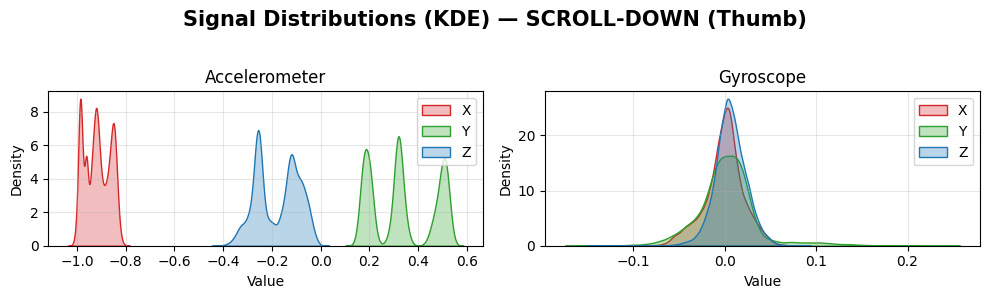

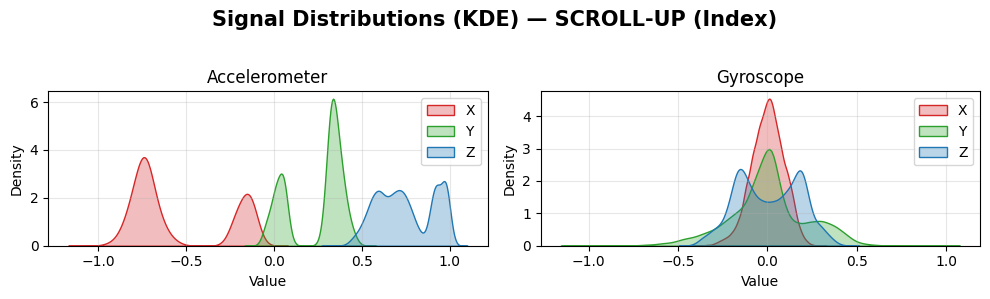

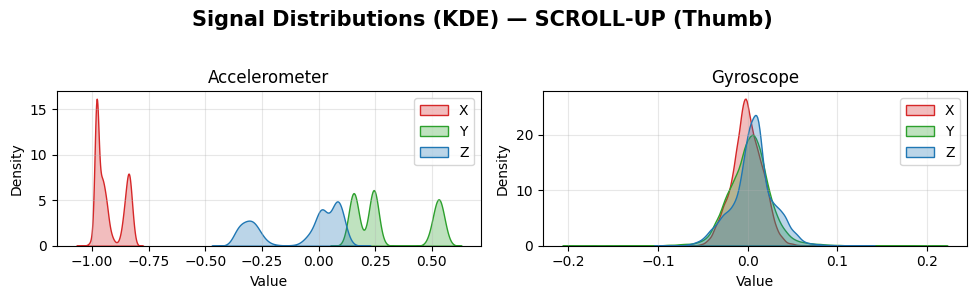

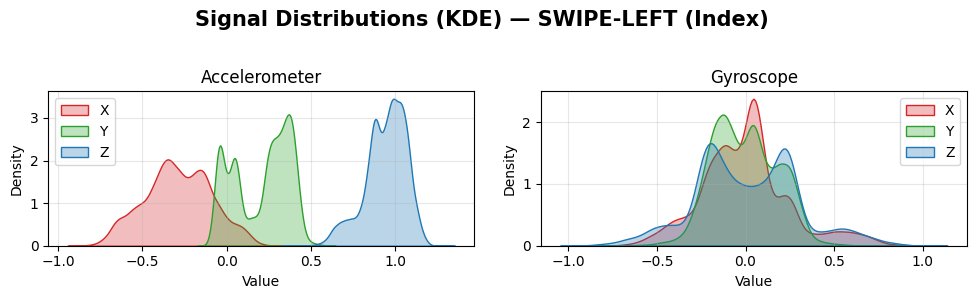

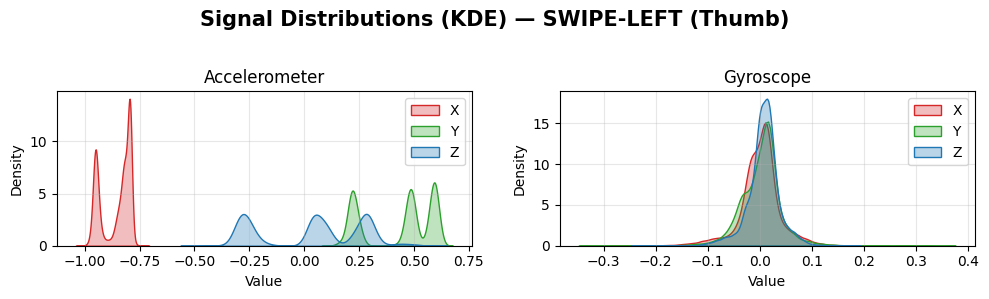

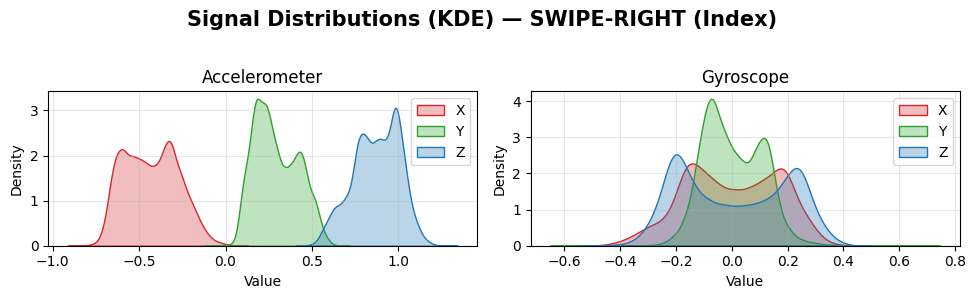

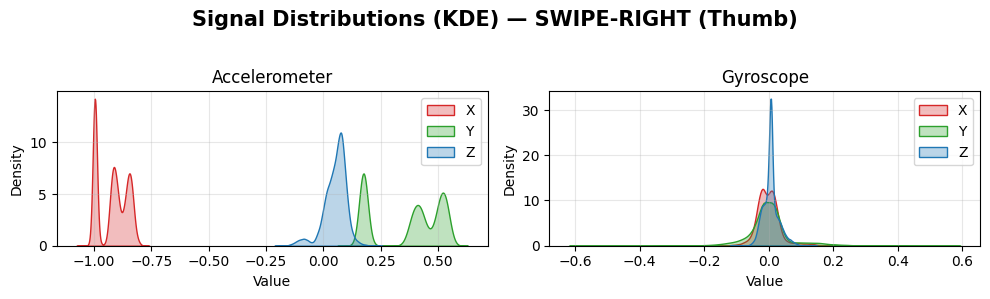

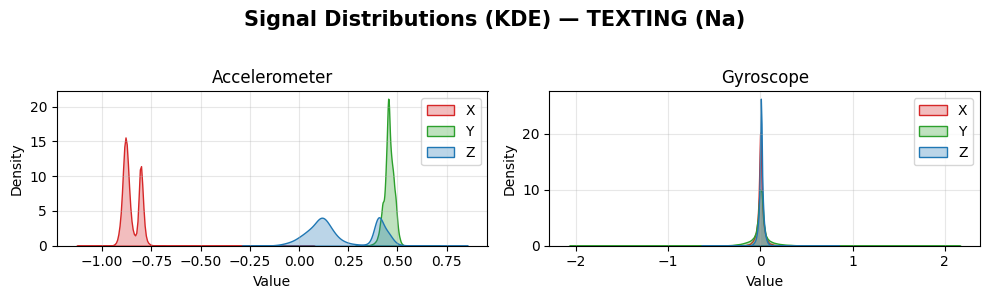

In [3]:
# Per-axis stats (mixed scaling)
desc = df_all[["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]].describe(percentiles=[.25, .5, .75]).T
desc["skew"] = df_all[["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]].skew()
desc["kurt"] = df_all[["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]].kurt()
save_results(desc.reset_index(), "eda_per_axis_stats")

# Class duration stats and signal distribution histograms
plot_average_durations(df_all)
plot_signal_histograms(df_all)

# 4. Time-Series Segmentation (Sliding Window) 
We apply a sliding window (ws=200 samples, overlap=100 samples) to chop the continuous sessions into discrete instances.

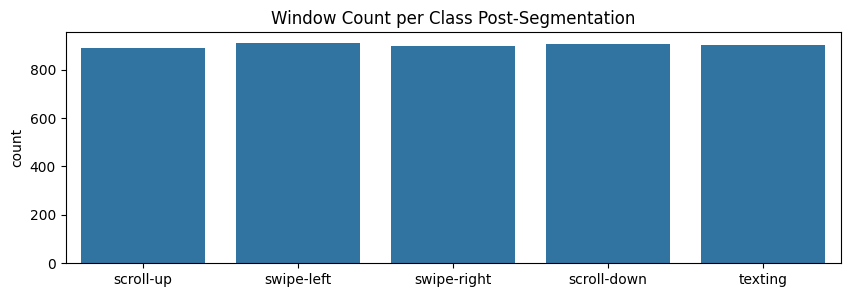

In [4]:
all_windows, all_labels, all_users, all_session_ids = [], [], [], []

# Segmentation using sliding window (per session)
for sid, sub in df_all.groupby("session_id"):
    df_sess = sub[["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]].reset_index(drop=True)
    label = sub["gesture_id"].iloc[0]
    user = sub["user"].iloc[0]
    
    windows = sliding_window_pd(
        df_sess,
        ws=cfg["sliding_window"]["ws"],
        overlap=cfg["sliding_window"]["overlap"],
        w_type=cfg["sliding_window"]["w_type"],
        w_center=cfg["sliding_window"].get("w_center", True),
        print_stats=False
    )
    
    all_windows.extend(windows)
    all_labels.extend([label] * len(windows))
    all_users.extend([user] * len(windows))
    all_session_ids.extend([sid] * len(windows))

# Post-segmentation class balance check
plot_windows_per_class(all_labels) 

# 5. Outlier Detection & Removal Ledger 
We scan the generated windows for corruption (NaN values, severe $z$-score outliers $>4$, and accelerometer saturation at 8g). Bad windows are dropped, and a strict ledger (preprocessing_removed_windows.csv) is generated for reporting transparency.

In [5]:
removal_rows, keep_mask = [], []

for idx, win in enumerate(all_windows):
    arr = win[["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]].values
    
    if np.isnan(arr).any():
        removal_rows.append({"idx": idx, "user": all_users[idx], "label": all_labels[idx], "reason": "NaN"})
        keep_mask.append(False)
        continue
        
    if (np.abs(zscore(arr, axis=0)) > 4).mean() > 0.05:
        removal_rows.append({"idx": idx, "user": all_users[idx], "label": all_labels[idx], "reason": "z>4 outliers >5%"})
        keep_mask.append(False)
        continue
        
    if (np.abs(arr[:, :3]) >= 7.9).any(): # acc saturation @ ±8g
        removal_rows.append({"idx": idx, "user": all_users[idx], "label": all_labels[idx], "reason": "acc saturation"})
        keep_mask.append(False)
        continue
        
    keep_mask.append(True)

removal_df = pd.DataFrame(removal_rows)
save_results(removal_df, "preprocessing_removed_windows")
print(f"Kept {sum(keep_mask)}/{len(keep_mask)} windows.")

# Apply masks
all_windows = [w for w, k in zip(all_windows, keep_mask) if k]
all_labels = [l for l, k in zip(all_labels, keep_mask) if k]
all_users = [u for u, k in zip(all_users, keep_mask) if k]

Kept 4506/4506 windows.


# 6. Subject-Based Train/Test Split 
To evaluate generalization and prevent data leakage, we perform a strict subject-based split. Users a and b form the training set, while user s is completely held out as the test set. No random shuffling is used, preventing overlapping windows from leaking into the test set.

In [6]:
users_arr = np.array(all_users)
labels_arr = np.array(all_labels)

train_mask = np.isin(users_arr, cfg["train_users"]) # ["a", "b"]
test_mask = np.isin(users_arr, cfg["test_users"])   # ["s"]

# Validation: NO subject leakage
assert set(users_arr[train_mask]).isdisjoint(set(users_arr[test_mask]))
print(f"Train windows: {train_mask.sum()}, Test windows: {test_mask.sum()}")

Train windows: 3012, Test windows: 1494


# 7. Segmented Cache Generation
The cleaned windows, labels, user IDs, and train/test masks are bundled into a segmented.pkl file. This acts as the single source of truth that both the Time-Series and Feature Engineering modeling notebooks will load.

In [7]:
cache_path = Path("outputs/cache/segmented.pkl")

with open(cache_path, "wb") as f:
    pickle.dump({
        "windows": all_windows,
        "labels": labels_arr,
        "users": users_arr,
        "train_mask": train_mask,
        "test_mask": test_mask,
    }, f)

print("Segmentation and Preprocessing caching complete.")

Segmentation and Preprocessing caching complete.
